In [16]:
import torch
from torch import nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
from torchvision.utils import make_grid,save_image
import os
import math

In [17]:
dir = "./wgan"
os.makedirs(dir,exist_ok=True)


In [18]:
transform = transforms.Compose([
    transforms.Resize(28),
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
])

In [19]:
data = datasets.MNIST(dir,train=True,transform=transform,download=True)

In [20]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [21]:
loader = DataLoader(data,batch_size=256,shuffle=True,num_workers=2,pin_memory=True)

In [22]:
len(loader)

235

In [23]:
nc=1
z_dim = 128
g_feat = 64
c_feat = 64
n_epochs = 30
lr = 1e-4
n_critic = 5
sample_every = 1
lambda_gp = 10.0
beta1,beta2 = 0.0,0.9


In [24]:
class Generator(nn.Module):
    def __init__(self, z_dim=128, ngf=64, nc=1):
        super().__init__()
        self.net = nn.Sequential(
                nn.ConvTranspose2d(z_dim, ngf*4, 7, 1, 0, bias=False),
                nn.BatchNorm2d(ngf*4), nn.ReLU(True),
                nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
                nn.BatchNorm2d(ngf*2), nn.ReLU(True),
                nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1, bias=False),
                nn.BatchNorm2d(ngf), nn.ReLU(True),
                nn.Conv2d(ngf, nc, 3, 1, 1, bias=False),
                nn.Tanh()
            )

    def forward(self, z):
        z = z.view(z.size(0), z.size(1), 1, 1)
        return self.net(z)

class Critic(nn.Module):
    def __init__(self, nc=1, ndf=64):
        super().__init__()
        self.net = nn.Sequential(
                nn.Conv2d(nc, ndf, 4, 2, 1, bias=False), nn.LeakyReLU(0.2, inplace=True),
                nn.Conv2d(ndf, ndf*2, 4, 2, 1, bias=False), nn.InstanceNorm2d(ndf*2, affine=True), nn.LeakyReLU(0.2, inplace=True),
                nn.Conv2d(ndf*2, 1, 7, 1, 0, bias=False),
            )

    def forward(self, x):
        return self.net(x).view(-1)

In [25]:
G = Generator(z_dim=z_dim, ngf=g_feat, nc=nc).to(device)
C = Critic(nc=nc, ndf=c_feat).to(device)

In [26]:
optC = torch.optim.Adam(C.parameters(), lr=lr, betas=(beta1, beta2))
optG = torch.optim.Adam(G.parameters(), lr=lr, betas=(beta1, beta2))

In [27]:
def gradient_penalty(critic, real, fake, device):
    batch_size = real.size(0)
    eps = torch.rand(batch_size, 1, 1, 1, device=device)
    x_hat = eps * real + (1 - eps) * fake
    x_hat.requires_grad_(True)
    out = critic(x_hat)
    grads = torch.autograd.grad(outputs=out, inputs=x_hat,
                                grad_outputs=torch.ones_like(out),only_inputs=True)[0]
    grads = grads.view(batch_size, -1)
    grad_norm = grads.norm(2, dim=1)
    gp = ((grad_norm - 1.0) ** 2).mean()
    return gp

In [28]:
fixed_noise = torch.randn(64, z_dim, device=device)

In [29]:
global_step = 0
for epoch in range(n_epochs):
    for i, (imgs, _) in enumerate(loader):
        imgs = imgs.to(device)
        for _ in range(n_critic):
            z = torch.randn(imgs.size(0), z_dim, device=device)
            fake = G(z)

            C.zero_grad()
            real_scores = C(imgs)
            fake_scores = C(fake.detach())
            loss_critic = fake_scores.mean() - real_scores.mean()
            gp = gradient_penalty(C, imgs, fake.detach(), device)
            loss_C_total = loss_critic + lambda_gp * gp
            loss_C_total.backward()
            optC.step()

        G.zero_grad()
        z = torch.randn(imgs.size(0), z_dim, device=device)
        fake = G(z)
        fake_scores_forG = C(fake)
        loss_G = - fake_scores_forG.mean()
        loss_G.backward()
        optG.step()

        global_step += 1

        if global_step % 200 == 0:
            print(f"Epoch[{epoch}/{n_epochs}] Step[{i}/{len(loader)}] LossC: {loss_C_total.item():.4f} LossG: {loss_G.item():.4f} GP: {gp.item():.4f}")

    if (epoch+1) % sample_every == 0:
        with torch.no_grad():
            samples = G(fixed_noise).cpu()
            grid = make_grid(samples, nrow=8, normalize=True, value_range=(-1,1))
            save_image(grid, os.path.join(dir, f"epoch_{epoch+1:03d}.png"))

Epoch[0/30] Step[199/235] LossC: 23492.6992 LossG: 31.1760 GP: 2356.1973
Epoch[1/30] Step[164/235] LossC: 137447.8906 LossG: 78.9704 GP: 13759.5684
Epoch[2/30] Step[129/235] LossC: 447228.4062 LossG: 76.5426 GP: 44741.3867
Epoch[3/30] Step[94/235] LossC: 1105930.5000 LossG: 32.0483 GP: 110613.6641
Epoch[4/30] Step[59/235] LossC: 2285493.0000 LossG: 37.1903 GP: 228578.1250
Epoch[5/30] Step[24/235] LossC: 4512222.5000 LossG: 27.9298 GP: 451251.0000
Epoch[5/30] Step[224/235] LossC: 6388035.0000 LossG: 253.2801 GP: 638839.6875
Epoch[6/30] Step[189/235] LossC: 9364586.0000 LossG: 52.5375 GP: 936498.1875
Epoch[7/30] Step[154/235] LossC: 12772643.0000 LossG: 80.2459 GP: 1277305.1250
Epoch[8/30] Step[119/235] LossC: 15770190.0000 LossG: 312.8979 GP: 1577071.6250
Epoch[9/30] Step[84/235] LossC: 24193642.0000 LossG: -203.3514 GP: 2419416.5000
Epoch[10/30] Step[49/235] LossC: 31413916.0000 LossG: 312.5407 GP: 3141451.0000
Epoch[11/30] Step[14/235] LossC: 37483516.0000 LossG: 97.2928 GP: 3748419.5

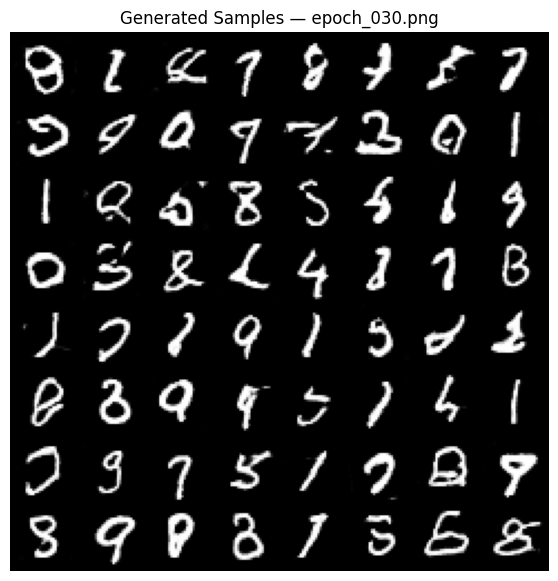

In [30]:
from PIL import Image

def show_generated_images(img_dir, epoch=None):

    files = [f for f in os.listdir(img_dir) if f.endswith(".png")]
    if not files:
        print("No images found in folder.")
        return

    if epoch is not None:
        fname = f"epoch_{epoch:03d}.png"
        if fname not in files:
            print(f"{fname} not found in directory.")
            return
    else:
        fname = sorted(files)[-1]

    # Load image
    path = os.path.join(img_dir, fname)
    img = Image.open(path)

    # Plot
    plt.figure(figsize=(7, 7))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Generated Samples — {fname}")
    plt.show()

show_generated_images(dir)
